In [1]:
!pip install tensorflow numpy matplotlib pillow


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


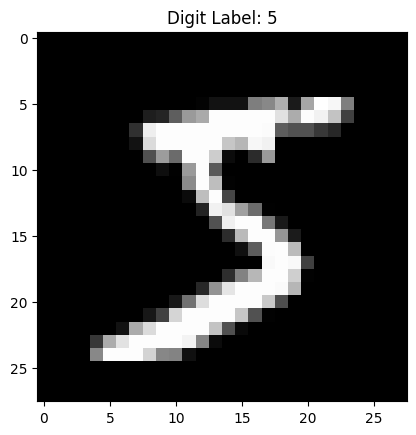

In [5]:
plt.imshow(x_train[0], cmap="gray")
plt.title("Digit Label: " + str(y_train[0]))
plt.show()

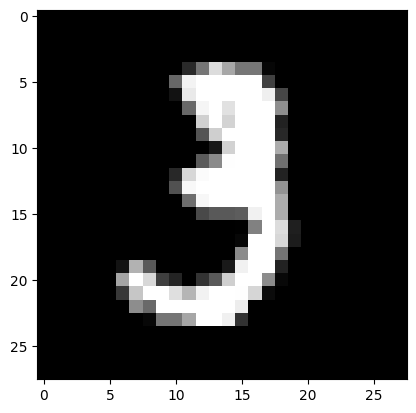

In [6]:
plt.imshow(x_train[10], cmap="gray")
plt.show()

In [7]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

c:\Users\sengu\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9256 - loss: 0.2595
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9668 - loss: 0.1132
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9765 - loss: 0.0779
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9824 - loss: 0.0591
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9861 - loss: 0.0454


In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9767 - loss: 0.0772
Test accuracy: 0.9767000079154968


In [12]:
prediction = model.predict(x_test)
print(np.argmax(prediction[0]))
print("Actual label:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
7
Actual label: 7


In [13]:
model.save("digit_model.h5")